In [1]:
# Install required libraries

!pip -q install pandas numpy matplotlib seaborn nltk spacy wordcloud openpyxl xlrd odfpy \
    scipy h5py librosa soundfile pydicom SimpleITK moviepy openpyxl lxml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.4 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import zipfile
import pickle
import sqlite3
import warnings
import urllib.request

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display, Audio, Video

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# URL of the Iris dataset
iris_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

# Download the dataset
urllib.request.urlretrieve(iris_url, "iris.csv")

print("iris.csv downloaded successfully!")

iris.csv downloaded successfully!


In [4]:
# Read CSV file
df_csv = pd.read_csv("iris.csv")

print("First 5 rows:")
display(df_csv.head())

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print("File name:", "iris.csv")
print("Number of rows:", df_csv.shape[0])
print("Number of columns:", df_csv.shape[1])
print("Shape:", df_csv.shape)
print("Dimensions:", df_csv.ndim)
print("Size:", df_csv.size)

print("\nData types:")
print(df_csv.dtypes)

print("\nMissing values:")
print(df_csv.isnull().sum())

File name: iris.csv
Number of rows: 150
Number of columns: 5
Shape: (150, 5)
Dimensions: 2
Size: 750

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


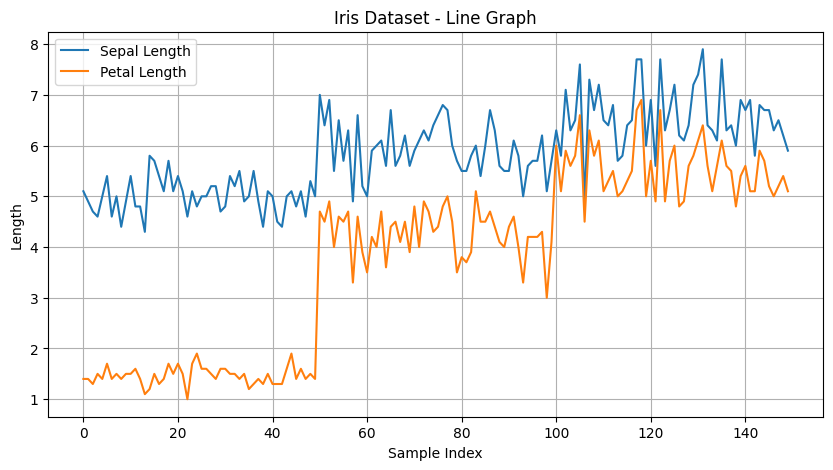

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(df_csv.index, df_csv["sepal_length"], label="Sepal Length")
plt.plot(df_csv.index, df_csv["petal_length"], label="Petal Length")

plt.title("Iris Dataset - Line Graph")
plt.xlabel("Sample Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)

plt.show()

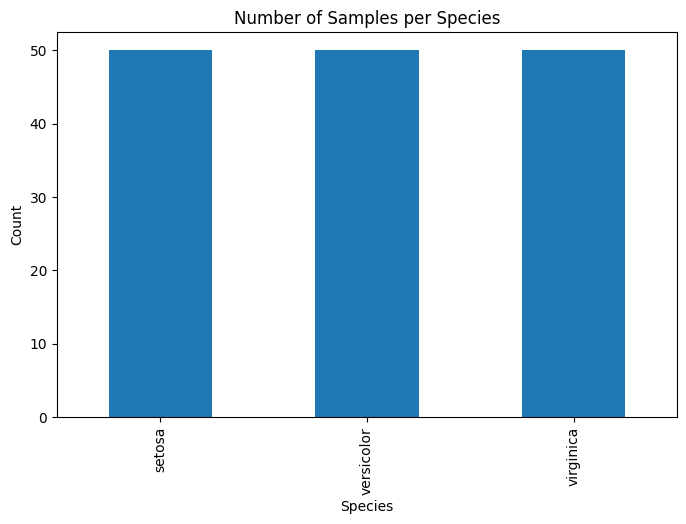

In [7]:
species_count = df_csv["species"].value_counts()

plt.figure(figsize=(8, 5))

species_count.plot(kind="bar")

plt.title("Number of Samples per Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

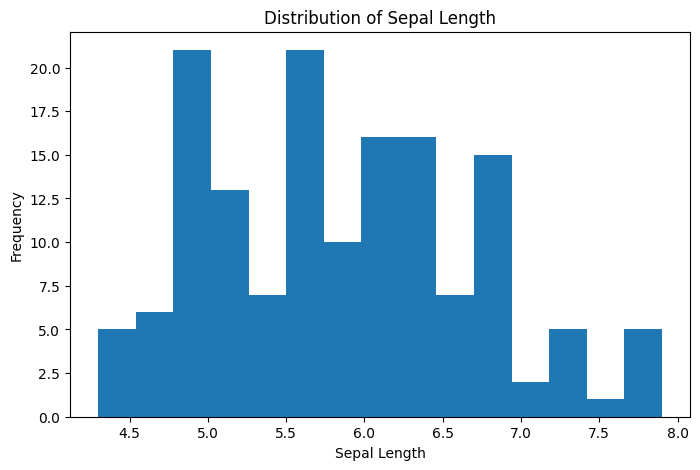

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df_csv["sepal_length"], bins=15)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")

plt.show()

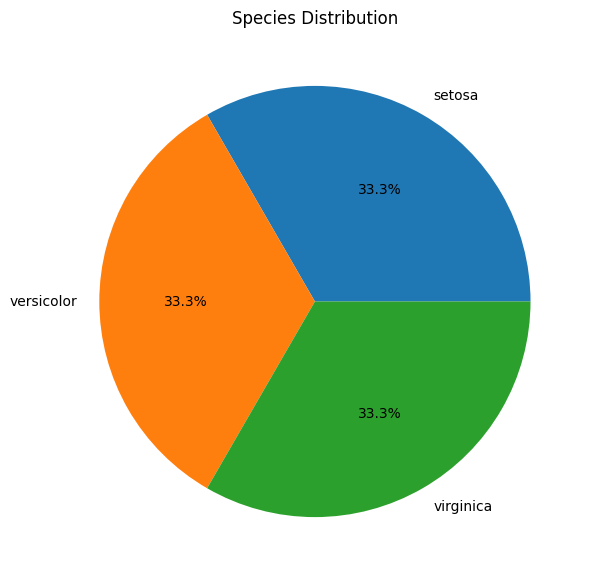

In [9]:
plt.figure(figsize=(7, 7))

df_csv["species"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Species Distribution")
plt.ylabel("")

plt.show()

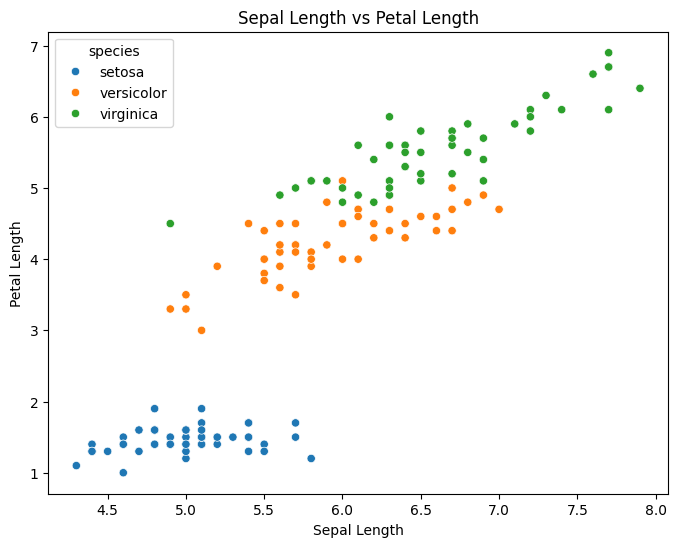

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_csv,
    x="sepal_length",
    y="petal_length",
    hue="species"
)

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.show()

In [11]:
# Create TSV from the downloaded dataset
df_csv.to_csv("iris.tsv", sep="\t", index=False)

# Read TSV
df_tsv = pd.read_csv("iris.tsv", sep="\t")

print("TSV Data:")
display(df_tsv.head())

print("\nShape:", df_tsv.shape)
print("Dimensions:", df_tsv.ndim)

TSV Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)
Dimensions: 2


In [12]:
# Create a .dat file using tabular data
df_csv.to_csv("iris.dat", sep="\t", index=False)

# Read DAT file
df_dat = pd.read_csv("iris.dat", sep="\t")

print("DAT Data:")
display(df_dat.head())

print("\nShape:", df_dat.shape)

DAT Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)


In [13]:
# Create an ARFF file manually

with open("iris.arff", "w") as f:

    f.write("@RELATION iris\n\n")

    f.write("@ATTRIBUTE sepal_length NUMERIC\n")
    f.write("@ATTRIBUTE sepal_width NUMERIC\n")
    f.write("@ATTRIBUTE petal_length NUMERIC\n")
    f.write("@ATTRIBUTE petal_width NUMERIC\n")
    f.write("@ATTRIBUTE species {setosa,versicolor,virginica}\n\n")

    f.write("@DATA\n")

    for _, row in df_csv.iterrows():
        f.write(
            f"{row['sepal_length']},"
            f"{row['sepal_width']},"
            f"{row['petal_length']},"
            f"{row['petal_width']},"
            f"{row['species']}\n"
        )

print("iris.arff created successfully!")

iris.arff created successfully!


In [14]:
from scipy.io import arff

data, metadata = arff.loadarff("iris.arff")

df_arff = pd.DataFrame(data)

# Decode byte strings
df_arff["species"] = df_arff["species"].str.decode("utf-8")

display(df_arff.head())

print("Shape:", df_arff.shape)
print("Dimensions:", df_arff.ndim)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)
Dimensions: 2


In [15]:
# Save dataset as Excel file
df_csv.to_excel("iris.xlsx", index=False)

# Read Excel file
df_xlsx = pd.read_excel("iris.xlsx")

print("XLSX Data:")
display(df_xlsx.head())

print("\nShape:", df_xlsx.shape)
print("Dimensions:", df_xlsx.ndim)

XLSX Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)
Dimensions: 2


In [16]:
# Save as OpenDocument Spreadsheet
df_csv.to_excel("iris.ods", engine="odf", index=False)

# Read ODS
df_ods = pd.read_excel("iris.ods", engine="odf")

print("ODS Data:")
display(df_ods.head())

print("\nShape:", df_ods.shape)

ODS Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)


In [17]:
# Save JSON
df_csv.to_json("iris.json", orient="records", indent=4)

# Read JSON
df_json = pd.read_json("iris.json")

print("JSON Data:")
display(df_json.head())

print("\nShape:", df_json.shape)
print("Dimensions:", df_json.ndim)

JSON Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)
Dimensions: 2


In [18]:
# Create HTML table
df_csv.to_html("iris.html", index=False)

# Read HTML
html_tables = pd.read_html("iris.html")

df_html = html_tables[0]

print("HTML Data:")
display(df_html.head())

print("\nShape:", df_html.shape)

HTML Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)


In [19]:
# Save DataFrame as XML
df_csv.to_xml("iris.xml", index=False)

print("XML file created successfully!")

XML file created successfully!


In [20]:
import xml.etree.ElementTree as ET

tree = ET.parse("iris.xml")
root = tree.getroot()

print("XML Root Tag:", root.tag)

print("\nFirst 3 records:")

for record in list(root)[:3]:
    print({
        child.tag: child.text
        for child in record
    })

XML Root Tag: data

First 3 records:
{'sepal_length': '5.1', 'sepal_width': '3.5', 'petal_length': '1.4', 'petal_width': '0.2', 'species': 'setosa'}
{'sepal_length': '4.9', 'sepal_width': '3.0', 'petal_length': '1.4', 'petal_width': '0.2', 'species': 'setosa'}
{'sepal_length': '4.7', 'sepal_width': '3.2', 'petal_length': '1.3', 'petal_width': '0.2', 'species': 'setosa'}


In [21]:
# Save DataFrame using Pickle
with open("iris.pkl", "wb") as f:
    pickle.dump(df_csv, f)

# Read Pickle
with open("iris.pkl", "rb") as f:
    df_pkl = pickle.load(f)

print("Pickle Data:")
display(df_pkl.head())

print("\nShape:", df_pkl.shape)

Pickle Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: (150, 5)


In [22]:
# Convert numeric columns to NumPy array
numpy_data = df_csv.iloc[:, :4].values

# Save
np.save("iris.npy", numpy_data)

# Load
loaded_npy = np.load("iris.npy")

print("NPY Data:")
print(loaded_npy[:5])

print("\nShape:", loaded_npy.shape)
print("Dimensions:", loaded_npy.ndim)

NPY Data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Shape: (150, 4)
Dimensions: 2


In [24]:
# Save NPZ
np.savez(
    "iris.npz",
    data=numpy_data
)

# Read NPZ
npz_data = np.load("iris.npz")

print("NPZ Keys:", npz_data.files)
print("NPZ Shape:", npz_data["data"].shape)

NPZ Keys: ['data']
NPZ Shape: (150, 4)


In [25]:
# Create ZIP file containing several files

with zipfile.ZipFile("iris_files.zip", "w") as zipf:

    zipf.write("iris.csv")
    zipf.write("iris.json")
    zipf.write("iris.xlsx")

print("ZIP file created successfully!")

# Read ZIP contents
with zipfile.ZipFile("iris_files.zip", "r") as zipf:

    print("Files inside ZIP:")
    print(zipf.namelist())

ZIP file created successfully!
Files inside ZIP:
['iris.csv', 'iris.json', 'iris.xlsx']


In [26]:
# Create SQLite database

connection = sqlite3.connect("iris.db")

# Store DataFrame in SQL table
df_csv.to_sql(
    "iris",
    connection,
    if_exists="replace",
    index=False
)

# Read from SQL
df_sql = pd.read_sql(
    "SELECT * FROM iris",
    connection
)

display(df_sql.head())

print("Shape:", df_sql.shape)

connection.close()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)


In [27]:
from scipy.io import savemat, loadmat

# Save data
savemat(
    "iris.mat",
    {
        "features": numpy_data
    }
)

# Read MAT file
mat_data = loadmat("iris.mat")

print("Variables in MAT file:")
print(mat_data.keys())

print("\nFeatures:")
print(mat_data["features"][:5])

print("\nShape:")
print(mat_data["features"].shape)

Variables in MAT file:
dict_keys(['__header__', '__version__', '__globals__', 'features'])

Features:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Shape:
(150, 4)


In [28]:
# Save DataFrame as HDF5
df_csv.to_hdf(
    "iris.h5",
    key="iris",
    mode="w"
)

# Read HDF5
df_hdf = pd.read_hdf(
    "iris.h5",
    key="iris"
)

display(df_hdf.head())

print("Shape:", df_hdf.shape)
print("Dimensions:", df_hdf.ndim)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)
Dimensions: 2


In [29]:
from PIL import Image
import requests
from io import BytesIO

image_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

response = requests.get(image_url)

image = Image.open(BytesIO(response.content))

print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image format: JPEG
Image size: (1546, 1213)
Image mode: RGB


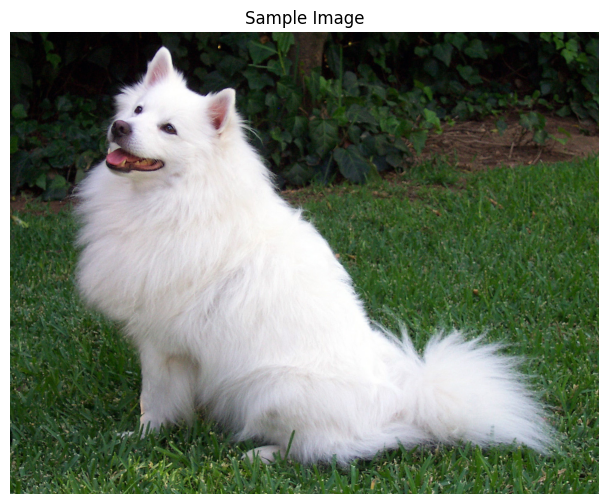

In [30]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.axis("off")
plt.title("Sample Image")

plt.show()

In [31]:
# Convert to RGB
image_rgb = image.convert("RGB")

# Save in different formats
image_rgb.save("sample.jpg")
image_rgb.save("sample.png")
image_rgb.save("sample.bmp")
image_rgb.save("sample.tiff")

print("JPG, PNG, BMP and TIFF files created.")

JPG, PNG, BMP and TIFF files created.


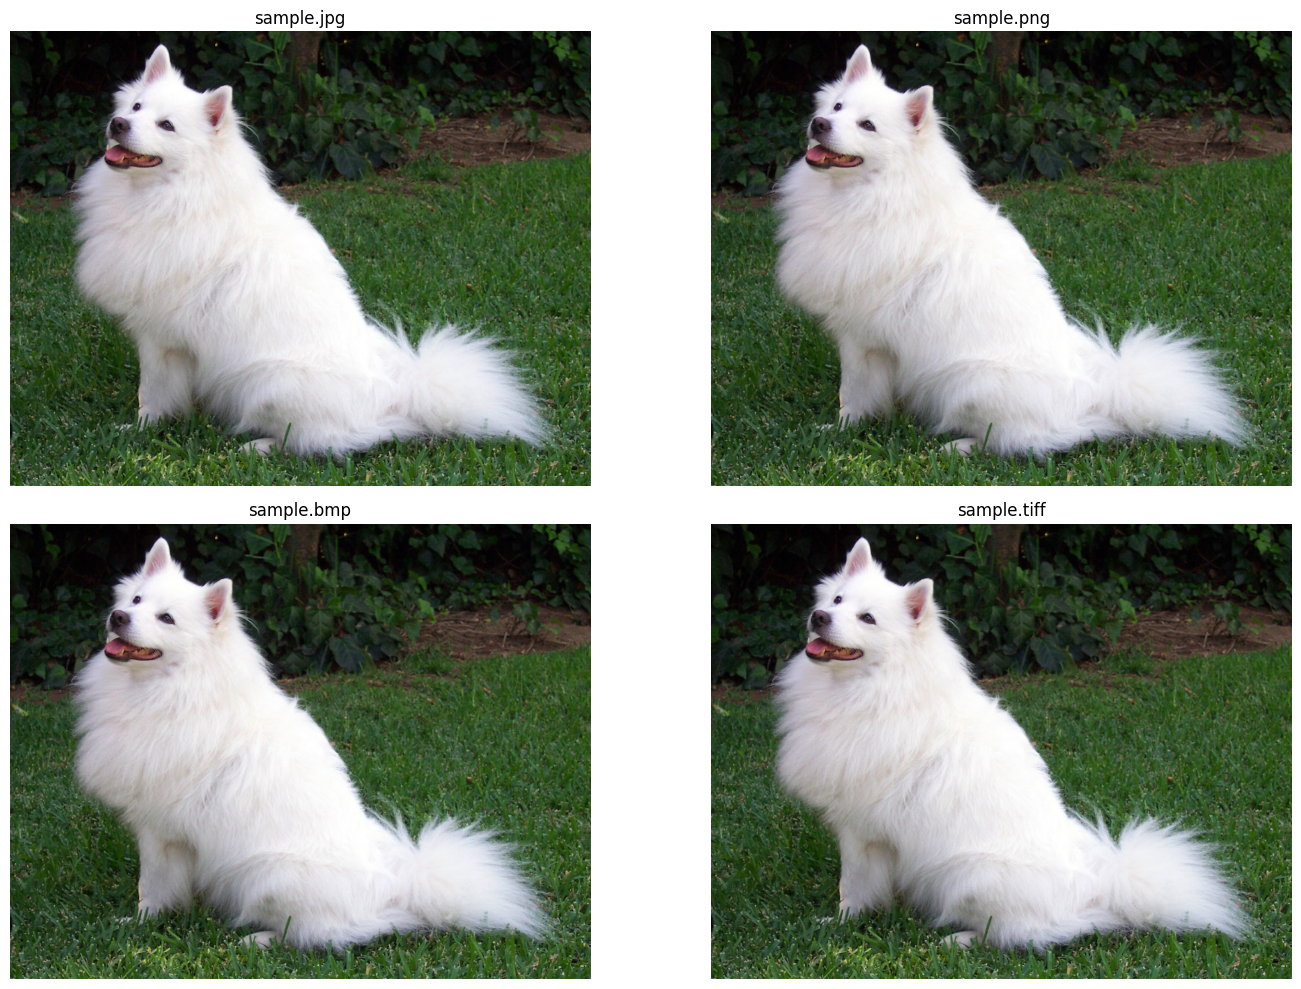

In [32]:
formats = [
    "sample.jpg",
    "sample.png",
    "sample.bmp",
    "sample.tiff"
]

plt.figure(figsize=(15, 10))

for i, file in enumerate(formats):

    img = Image.open(file)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

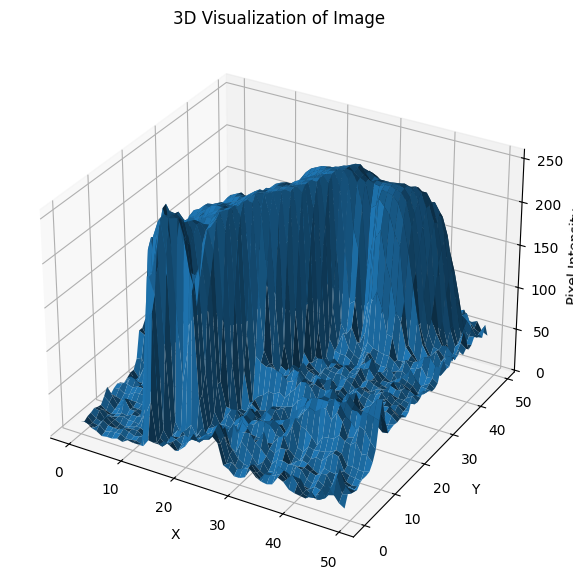

In [33]:
from mpl_toolkits.mplot3d import Axes3D

img_array = np.array(image_rgb)

# Resize for faster plotting
small_img = Image.fromarray(img_array).resize((50, 50))
small_img = np.array(small_img)

x = np.arange(small_img.shape[1])
y = np.arange(small_img.shape[0])

X, Y = np.meshgrid(x, y)

Z = small_img[:, :, 0]

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z)

ax.set_title("3D Visualization of Image")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Pixel Intensity")

plt.show()

In [34]:
video_url = "https://github.com/rafaelreis-hotmart/Audio-Sample-files/raw/master/sample.mp4"

urllib.request.urlretrieve(
    video_url,
    "sample.mp4"
)

print("Video downloaded successfully!")

Video downloaded successfully!


In [35]:
Video("sample.mp4", embed=True)

In [36]:
import cv2

video = cv2.VideoCapture("sample.mp4")

fps = video.get(cv2.CAP_PROP_FPS)
frame_count = video.get(cv2.CAP_PROP_FRAME_COUNT)
width = video.get(cv2.CAP_PROP_FRAME_WIDTH)
height = video.get(cv2.CAP_PROP_FRAME_HEIGHT)

duration = frame_count / fps if fps else 0

print("Width:", width)
print("Height:", height)
print("FPS:", fps)
print("Number of Frames:", frame_count)
print("Duration:", duration, "seconds")

video.release()

Width: 480.0
Height: 270.0
FPS: 30.0
Number of Frames: 901.0
Duration: 30.033333333333335 seconds


In [37]:
wav_url = "https://github.com/rafaelreis-hotmart/Audio-Sample-files/raw/master/sample.wav"
mp3_url = "https://github.com/rafaelreis-hotmart/Audio-Sample-files/raw/master/sample2.mp3"

urllib.request.urlretrieve(wav_url, "sample.wav")
urllib.request.urlretrieve(mp3_url, "sample.mp3")

print("Audio files downloaded!")

Audio files downloaded!


In [38]:
Audio("sample.wav")

In [39]:
import librosa

audio, sample_rate = librosa.load(
    "sample.wav",
    sr=None
)

print("Sample Rate:", sample_rate)
print("Number of Samples:", len(audio))
print("Duration:", len(audio) / sample_rate, "seconds")
print("Dimensions:", audio.ndim)

Sample Rate: 16000
Number of Samples: 234801
Duration: 14.6750625 seconds
Dimensions: 1


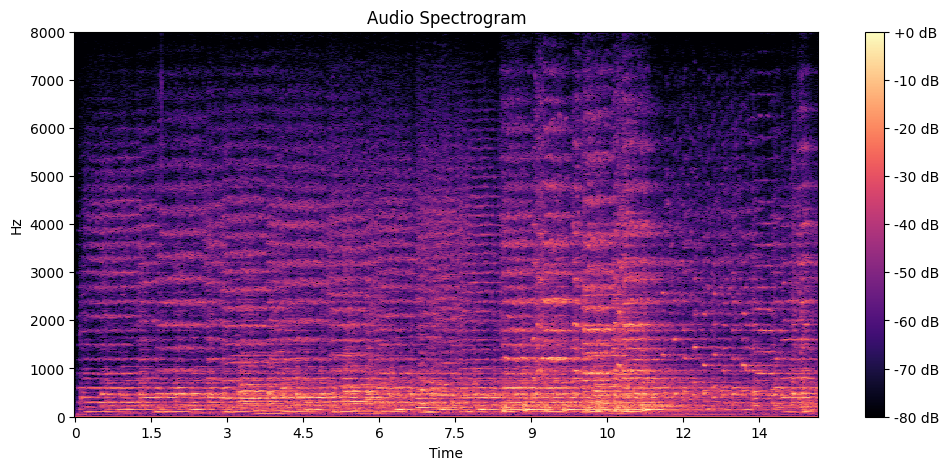

In [40]:
plt.figure(figsize=(12, 5))

D = librosa.amplitude_to_db(
    np.abs(librosa.stft(audio)),
    ref=np.max
)

librosa.display.specshow(
    D,
    sr=sample_rate,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Audio Spectrogram")

plt.show()

In [41]:
text = """
Natural Language Processing is a field of Artificial Intelligence.
It allows computers to understand human language.
NLP is used in chatbots, sentiment analysis, translation and search engines.
"""

with open("sample.txt", "w") as f:
    f.write(text)

with open("sample.txt", "r") as f:
    txt_data = f.read()

print(txt_data)


Natural Language Processing is a field of Artificial Intelligence.
It allows computers to understand human language.
NLP is used in chatbots, sentiment analysis, translation and search engines.



In [42]:
!pip -q install reportlab pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 33.3 MB/s eta 0:00:00


In [43]:
from reportlab.pdfgen import canvas

pdf_file = "sample.pdf"

c = canvas.Canvas(pdf_file)

c.drawString(
    100,
    750,
    "Natural Language Processing is a field of Artificial Intelligence."
)

c.drawString(
    100,
    730,
    "NLP allows computers to understand human language."
)

c.save()

print("PDF created successfully!")

PDF created successfully!


In [44]:
from pypdf import PdfReader

reader = PdfReader("sample.pdf")

pdf_text = ""

for page in reader.pages:
    pdf_text += page.extract_text()

print(pdf_text)

Natural Language Processing is a field of Artificial Intelligence.
NLP allows computers to understand human language.



In [45]:
!pip -q install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.6 MB/s eta 0:00:00


In [46]:
from docx import Document

document = Document()

document.add_heading(
    "Natural Language Processing",
    level=1
)

document.add_paragraph(
    "NLP is a field of Artificial Intelligence that "
    "allows computers to process human language."
)

document.save("sample.docx")

print("DOCX created successfully!")

DOCX created successfully!


In [47]:
document = Document("sample.docx")

doc_text = ""

for paragraph in document.paragraphs:
    doc_text += paragraph.text + "\n"

print(doc_text)

Natural Language Processing
NLP is a field of Artificial Intelligence that allows computers to process human language.



In [48]:
import nltk

nltk.download("brown")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

print("NLTK resources downloaded!")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK resources downloaded!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [49]:
import re

import nltk
from nltk.corpus import brown
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

In [50]:
paragraphs = [

"""OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!!
It was soooo gooood lol. I <3 nlp butttt i hate spelng errors in textttt.
This is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%.
The website's link is www.example.com//// Check it out ASAP!!! #excited""",

"""Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide web.
This article, "The Marvels of Artificial General Intelligence & the Future of Humanity,"
totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz.
I mean, I <3 NLP butttt those annoying typos in texts drive me nuts. Brace yourselves,
this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces
and some seriously weird symbols like @#$%. And guess what? The link to the website is
www.incrediblenews.com//// So, um, you better check it out like ASAP!!! #excitedmuch""",

"""yaaayyyy!!! just watched thisssss AMAZZZING vid on AI          evrythinggg!!
& how it’s changin' it waz soooo dopeee, i can’t even... lolzzz!
#blessed #mindblownn... btw, the link is http://coolai.stuff.com////
totally worthhh ittttttt @@@!!! i <3 tech so much but sometimes it's likee realllyyy confusingggg!!!""",

"""nooo waayyyyy!!!!                    their blogsssss
this is, like, the 1000000th time i've seen ppl mess up spellings in
i mean c'mon, u're writing abt deep learning, not sum joke topic
anywayzzzz... the article was kinda cooool butttt had lotsa weird $$$%%%@@ symbols all over.
you can read it @ www.badblogger.ai//// and let me knw ur thots ASAP!!!""",

"""heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai??
like for realll... it wuz crazzzzy detailed but sooooo complicateddd!!!
i cud barely undrstnd half of it                               diagrams were      . the tho!!!
i found it here – www.quantmgeekzz.net//// … plz plz plz read n tell me what you thinkk
#toomuchinfo #brainhurts @@@!!!"""
]

print("Number of paragraphs:", len(paragraphs))

Number of paragraphs: 5


In [51]:
def lowercase_text(text):
    return text.lower()


lowercase_paragraphs = [
    lowercase_text(text)
    for text in paragraphs
]

print(lowercase_paragraphs[0])

omg!! i can't believe i found this awesome article about ai & machine leanring!! 
it was soooo gooood lol. i <3 nlp butttt i hate spelng errors in textttt. 
this is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
the website's link is www.example.com//// check it out asap!!! #excited


In [52]:
def remove_urls(text):

    # Remove http/https URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        "",
        text
    )

    return text


url_cleaned = [
    remove_urls(text)
    for text in lowercase_paragraphs
]

print(url_cleaned[0])

omg!! i can't believe i found this awesome article about ai & machine leanring!! 
it was soooo gooood lol. i <3 nlp butttt i hate spelng errors in textttt. 
this is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
the website's link is  check it out asap!!! #excited


In [53]:
contractions = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would",
    "it's": "it is",
    "that's": "that is",
    "what's": "what is",
    "you're": "you are",
    "u're": "you are",
    "they're": "they are",
    "we're": "we are",
    "couldn't": "could not",
    "shouldn't": "should not",
    "wouldn't": "would not"
}


def expand_contractions(text):

    for contraction, expansion in contractions.items():

        text = re.sub(
            r"\b" + re.escape(contraction) + r"\b",
            expansion,
            text
        )

    return text


expanded_paragraphs = [
    expand_contractions(text)
    for text in url_cleaned
]

print(expanded_paragraphs[0])

omg!! i cannot believe i found this awesome article about ai & machine leanring!! 
it was soooo gooood lol. i <3 nlp butttt i hate spelng errors in textttt. 
this is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
the website's link is  check it out asap!!! #excited


In [54]:
def replace_emoticons(text):

    text = text.replace("<3", " love ")

    return text


emotion_cleaned = [
    replace_emoticons(text)
    for text in expanded_paragraphs
]

print(emotion_cleaned[0])

omg!! i cannot believe i found this awesome article about ai & machine leanring!! 
it was soooo gooood lol. i  love  nlp butttt i hate spelng errors in textttt. 
this is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
the website's link is  check it out asap!!! #excited


In [55]:
def remove_special_characters(text):

    # Keep alphabets, numbers and spaces
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    return text


special_cleaned = [
    remove_special_characters(text)
    for text in emotion_cleaned
]

print(special_cleaned[0])

omg   i cannot believe i found this awesome article about ai   machine leanring   
it was soooo gooood lol  i  love  nlp butttt i hate spelng errors in textttt  
this is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols       
the website s link is  check it out asap     excited


In [56]:
def reduce_duplicate_letters(text):

    # Four or more repeated characters -> one
    text = re.sub(
        r"(.)\1{3,}",
        r"\1",
        text
    )

    # Three repeated characters -> two
    text = re.sub(
        r"(.)\1{2}",
        r"\1\1",
        text
    )

    return text


duplicate_cleaned = [
    reduce_duplicate_letters(text)
    for text in special_cleaned
]

print(duplicate_cleaned[0])

omg  i cannot believe i found this awesome article about ai  machine leanring  
it was so god lol  i  love  nlp but i hate spelng errors in text  
this is gonna be a loong paragraph with lots of spacess and weird symbols 
the website s link is  check it out asap excited


In [57]:
def normalize_whitespace(text):

    # Replace multiple spaces with one space
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


cleaned_paragraphs = [
    normalize_whitespace(text)
    for text in duplicate_cleaned
]

for i, text in enumerate(cleaned_paragraphs):

    print(f"\nParagraph {i+1}:")
    print(text)


Paragraph 1:
omg i cannot believe i found this awesome article about ai machine leanring it was so god lol i love nlp but i hate spelng errors in text this is gonna be a loong paragraph with lots of spacess and weird symbols the website s link is check it out asap excited

Paragraph 2:
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the future of humanity totally blew my mind it was like soo mind blowingly awesome lolz i mean i love nlp but those annoying typos in texts drive me nuts brace yourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is so um you better check it out like asap excitedmuch

Paragraph 3:
yaay just watched this amazzing vid on ai evrythingg how it s changin it waz so dopee i can t even lolzz blessed mindblownn btw the link is totally worthh it

In [58]:
corrections = {
    "leanring": "learning",
    "spelng": "spelling",
    "textttt": "text",
    "gooood": "good",
    "loooong": "long",
    "looooots": "lots",
    "weirddddd": "weird",
    "mindddd": "mind",
    "butttt": "but",
    "lolz": "lol",
    "yaaayyyy": "yay",
    "thisssss": "this",
    "amazzzing": "amazing",
    "evrything": "everything",
    "changin": "changing",
    "waz": "was",
    "dopeee": "dope",
    "lolzzz": "lol",
    "mindblownn": "mindblown",
    "waayyyyy": "way",
    "blogsssss": "blogs",
    "anywayzzzz": "anyway",
    "cooool": "cool",
    "lotsa": "lots of",
    "knw": "know",
    "thots": "thoughts",
    "heyyyyy": "hey",
    "crazyyyyyyy": "crazy",
    "realll": "real",
    "crazzzzy": "crazy",
    "complicateddd": "complicated",
    "undrstnd": "understand",
    "thinkk": "think",
    "plz": "please"
}


def correct_spelling(text):

    words = text.split()

    corrected_words = []

    for word in words:

        if word in corrections:
            corrected_words.append(corrections[word])
        else:
            corrected_words.append(word)

    return " ".join(corrected_words)


final_cleaned_paragraphs = [
    correct_spelling(text)
    for text in cleaned_paragraphs
]

In [59]:
for i, text in enumerate(final_cleaned_paragraphs):

    print("=" * 80)
    print(f"CLEANED PARAGRAPH {i+1}")
    print("=" * 80)
    print(text)
    print()

CLEANED PARAGRAPH 1
omg i cannot believe i found this awesome article about ai machine learning it was so god lol i love nlp but i hate spelling errors in text this is gonna be a loong paragraph with lots of spacess and weird symbols the website s link is check it out asap excited

CLEANED PARAGRAPH 2
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the future of humanity totally blew my mind it was like soo mind blowingly awesome lol i mean i love nlp but those annoying typos in texts drive me nuts brace yourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is so um you better check it out like asap excitedmuch

CLEANED PARAGRAPH 3
yaay just watched this amazzing vid on ai evrythingg how it s changing it was so dopee i can t even lolzz blessed mindblown btw the link

In [60]:
from nltk.corpus import brown

brown_words = brown.words(
    categories="news"
)

print("Number of words:", len(brown_words))

print("\nFirst 50 words:")
print(brown_words[:50])

Number of words: 100554

First 50 words:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise']


In [61]:
brown_text = " ".join(brown_words)

print("Brown Corpus converted into string.")
print("\nFirst 500 characters:")
print(brown_text[:500])

Brown Corpus converted into string.

First 500 characters:
The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place . The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted . The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to invest


In [62]:
tokens = word_tokenize(brown_text)

print("Total tokens:", len(tokens))

print("\nFirst 50 tokens:")
print(tokens[:50])

Total tokens: 101929

First 50 tokens:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``', 'that', 'any', 'irregularities', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the']


In [63]:
clean_tokens = [
    word.lower()
    for word in tokens
    if word.isalpha()
]

print("Total alphabetic tokens:", len(clean_tokens))

print("\nFirst 50 cleaned tokens:")
print(clean_tokens[:50])

Total alphabetic tokens: 84650

First 50 cleaned tokens:
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'atlanta', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', 'the', 'jury', 'further', 'said', 'in', 'presentments', 'that', 'the', 'city', 'executive', 'committee', 'which', 'had', 'charge', 'of', 'the', 'election', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'city', 'of', 'atlanta', 'for']


In [64]:
frequency_distribution = Counter(clean_tokens)

print("Top 20 most frequent words:")

for word, count in frequency_distribution.most_common(20):

    print(f"{word}: {count}")

Top 20 most frequent words:
the: 6386
of: 2861
and: 2186
to: 2144
a: 2139
in: 2020
for: 969
that: 843
is: 740
was: 720
on: 691
he: 658
at: 636
with: 567
be: 526
as: 517
by: 504
it: 504
his: 428
said: 406


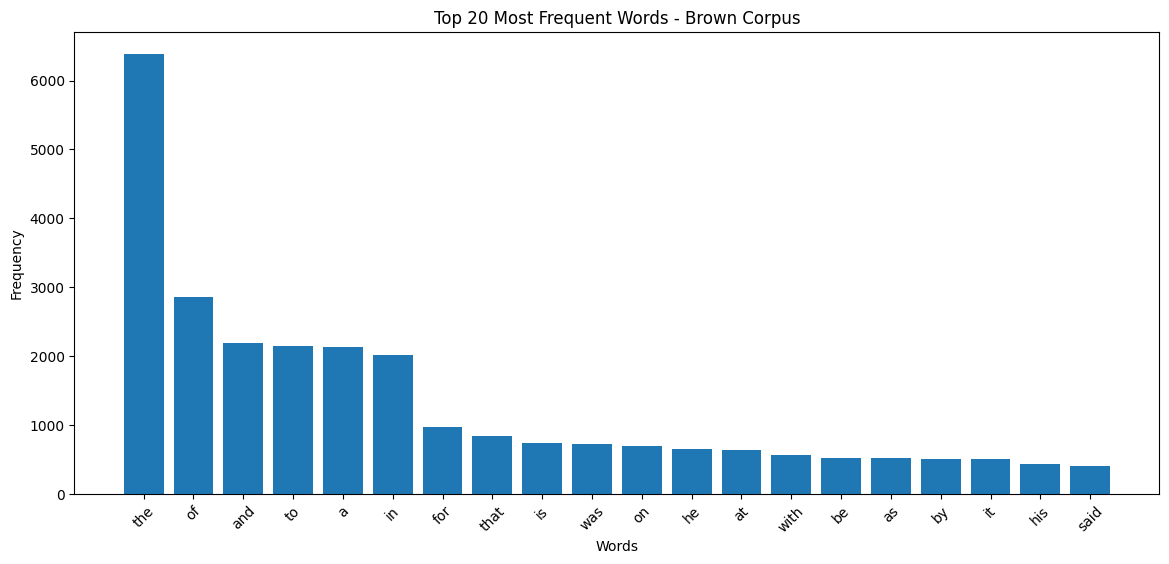

In [65]:
top_20 = frequency_distribution.most_common(20)

words = [item[0] for item in top_20]
counts = [item[1] for item in top_20]

plt.figure(figsize=(14, 6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words - Brown Corpus")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

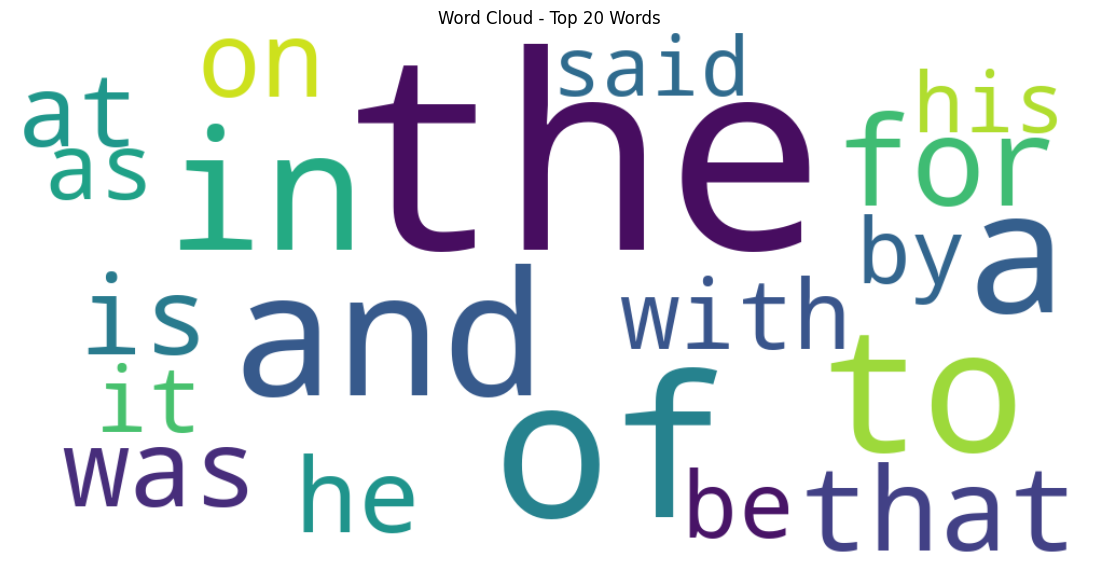

In [66]:
top_20_dict = dict(
    frequency_distribution.most_common(20)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(top_20_dict)

plt.figure(figsize=(15, 7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Word Cloud - Top 20 Words")

plt.show()

In [67]:
stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in clean_tokens
]

print("Original → Stemmed")

for original, stemmed in list(
    zip(clean_tokens, stemmed_words)
)[:50]:

    print(f"{original} → {stemmed}")

Original → Stemmed
the → the
fulton → fulton
county → counti
grand → grand
jury → juri
said → said
friday → friday
an → an
investigation → investig
of → of
atlanta → atlanta
recent → recent
primary → primari
election → elect
produced → produc
no → no
evidence → evid
that → that
any → ani
irregularities → irregular
took → took
place → place
the → the
jury → juri
further → further
said → said
in → in
presentments → present
that → that
the → the
city → citi
executive → execut
committee → committe
which → which
had → had
charge → charg
of → of
the → the
election → elect
deserves → deserv
the → the
praise → prais
and → and
thanks → thank
of → of
the → the
city → citi
of → of
atlanta → atlanta
for → for


In [68]:
stem_frequency = Counter(stemmed_words)

print("Top 30 stemmed words:\n")

for word, count in stem_frequency.most_common(30):

    print(f"{word}: {count}")

Top 30 stemmed words:

the: 6386
of: 2861
and: 2186
to: 2144
a: 2139
in: 2020
for: 969
that: 843
is: 740
wa: 720
on: 691
it: 682
he: 658
at: 636
be: 583
with: 567
as: 517
by: 504
hi: 428
said: 406
will: 396
from: 353
are: 334
thi: 320
an: 311
ha: 304
had: 283
but: 283
have: 279
they: 278


In [69]:
stem_table = pd.DataFrame(
    stem_frequency.most_common(30),
    columns=["Stem", "Frequency"]
)

display(stem_table)

,Stem,Frequency
0,the,6386
1,of,2861
2,and,2186
3,to,2144
4,a,2139
5,in,2020
6,for,969
7,that,843
8,is,740
9,wa,720


In [70]:
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in clean_tokens
]

print("Original → Lemmatized")

for original, lemma in list(
    zip(clean_tokens, lemmatized_words)
)[:50]:

    print(f"{original} → {lemma}")

Original → Lemmatized
the → the
fulton → fulton
county → county
grand → grand
jury → jury
said → said
friday → friday
an → an
investigation → investigation
of → of
atlanta → atlanta
recent → recent
primary → primary
election → election
produced → produced
no → no
evidence → evidence
that → that
any → any
irregularities → irregularity
took → took
place → place
the → the
jury → jury
further → further
said → said
in → in
presentments → presentment
that → that
the → the
city → city
executive → executive
committee → committee
which → which
had → had
charge → charge
of → of
the → the
election → election
deserves → deserves
the → the
praise → praise
and → and
thanks → thanks
of → of
the → the
city → city
of → of
atlanta → atlanta
for → for


In [71]:
lemma_frequency = Counter(lemmatized_words)

print("Top 30 lemmatized words:\n")

for word, count in lemma_frequency.most_common(30):

    print(f"{word}: {count}")

Top 30 lemmatized words:

the: 6386
of: 2861
a: 2656
and: 2186
to: 2144
in: 2020
for: 969
that: 843
is: 740
wa: 720
on: 691
it: 682
he: 658
at: 636
with: 567
be: 526
by: 504
his: 428
said: 406
will: 389
from: 353
are: 334
this: 320
an: 311
ha: 304
had: 283
but: 283
they: 278
not: 272
who: 268


In [72]:
lemma_table = pd.DataFrame(
    lemma_frequency.most_common(30),
    columns=["Lemma", "Frequency"]
)

display(lemma_table)

,Lemma,Frequency
0,the,6386
1,of,2861
2,a,2656
3,and,2186
4,to,2144
5,in,2020
6,for,969
7,that,843
8,is,740
9,wa,720


In [73]:
# Get common words between stemmed and lemmatized vocabularies

common_words = list(
    set(stem_frequency.keys())
    &
    set(lemma_frequency.keys())
)

# Select 15 words
common_words = common_words[:15]

comparison_data = []

for word in common_words:

    comparison_data.append({
        "Word": word,
        "Stem Frequency": stem_frequency[word],
        "Lemma Frequency": lemma_frequency[word]
    })


comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Word,Stem Frequency,Lemma Frequency
0,via,2,2
1,chrome,1,1
2,quell,1,1
3,difficult,8,8
4,sp,2,2
5,paget,1,1
6,paradox,4,2
7,eighth,2,2
8,scratch,4,3
9,c,4,4


In [74]:
comparison_words = [
    "government",
    "people",
    "state",
    "year",
    "new",
    "president",
    "school",
    "group",
    "company",
    "time",
    "world",
    "american",
    "country",
    "program",
    "work"
]

comparison_rows = []

for word in comparison_words:

    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)

    comparison_rows.append({
        "Original Word": word,
        "Stemmed Word": stem,
        "Lemmatized Word": lemma
    })


comparison_table = pd.DataFrame(
    comparison_rows
)

display(comparison_table)

,Original Word,Stemmed Word,Lemmatized Word
0,government,govern,government
1,people,peopl,people
2,state,state,state
3,year,year,year
4,new,new,new
5,president,presid,president
6,school,school,school
7,group,group,group
8,company,compani,company
9,time,time,time


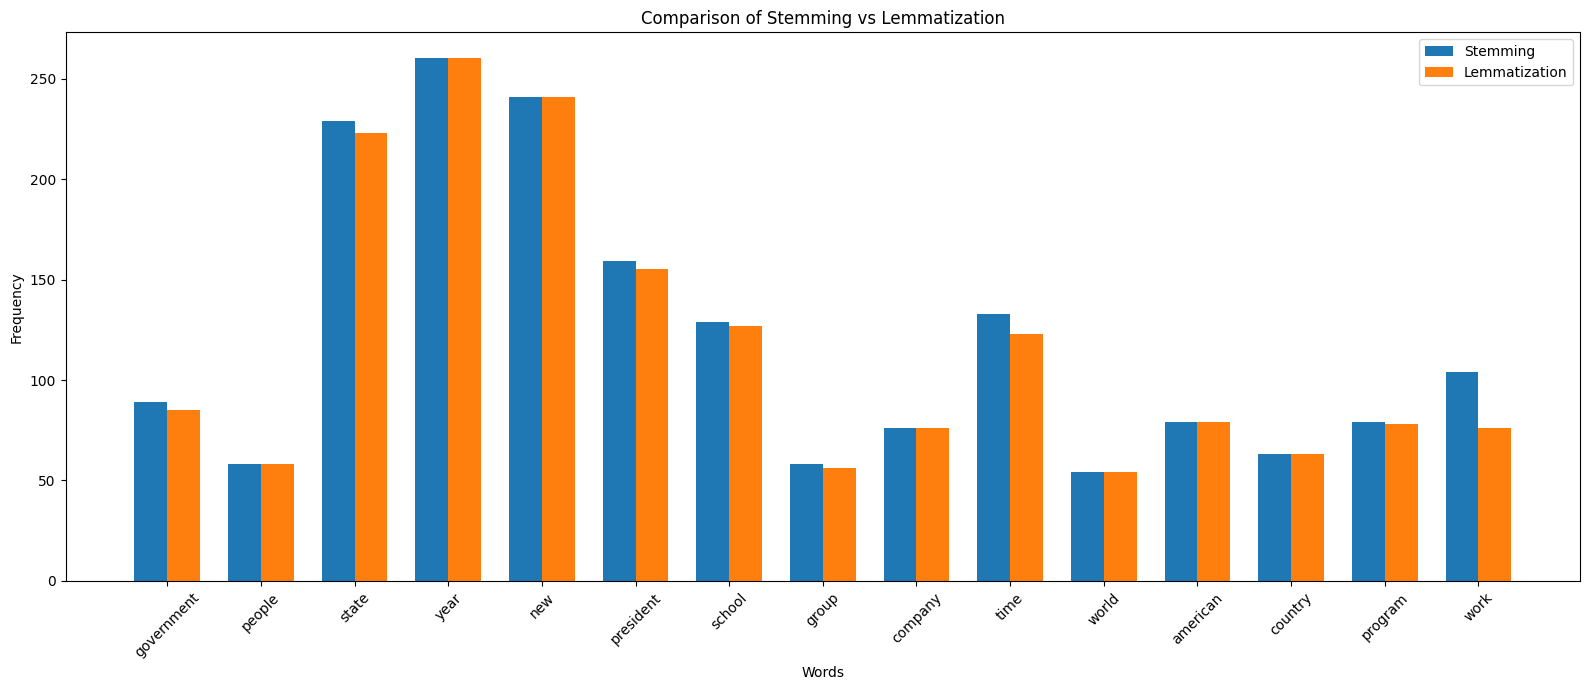

In [75]:
# Frequency comparison for the selected words

stem_counts = [
    stem_frequency[stemmer.stem(word)]
    for word in comparison_words
]

lemma_counts = [
    lemma_frequency[lemmatizer.lemmatize(word)]
    for word in comparison_words
]

x = np.arange(len(comparison_words))

width = 0.35

plt.figure(figsize=(16, 7))

plt.bar(
    x - width/2,
    stem_counts,
    width,
    label="Stemming"
)

plt.bar(
    x + width/2,
    lemma_counts,
    width,
    label="Lemmatization"
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.title(
    "Comparison of Stemming vs Lemmatization"
)

plt.xticks(
    x,
    comparison_words,
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.show()

In [76]:
print("=" * 70)
print("LAB ASSIGNMENT 1 - SUMMARY")
print("=" * 70)

print("\nTask 1:")
print("✓ Read multiple data formats")
print("✓ Checked file properties")
print("✓ Visualized tabular data")
print("✓ Displayed image data")
print("✓ Displayed video")
print("✓ Played audio")
print("✓ Generated audio spectrogram")
print("✓ Parsed text, PDF and DOCX")

print("\nTask 2:")
print("✓ Loaded Brown Corpus")
print("✓ Tokenized text")
print("✓ Calculated word frequencies")
print("✓ Created bar chart")
print("✓ Created word cloud")
print("✓ Applied Porter Stemming")
print("✓ Applied WordNet Lemmatization")
print("✓ Compared stemming and lemmatization")

print("\nAssignment completed successfully!")

LAB ASSIGNMENT 1 - SUMMARY

Task 1:
✓ Read multiple data formats
✓ Checked file properties
✓ Visualized tabular data
✓ Displayed image data
✓ Displayed video
✓ Played audio
✓ Generated audio spectrogram
✓ Parsed text, PDF and DOCX

Task 2:
✓ Loaded Brown Corpus
✓ Tokenized text
✓ Calculated word frequencies
✓ Created bar chart
✓ Created word cloud
✓ Applied Porter Stemming
✓ Applied WordNet Lemmatization
✓ Compared stemming and lemmatization

Assignment completed successfully!
